In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [7]:
df = pd.read_csv("/kaggle/input/datasets/pragatigupta127/tweets1/Tweets.csv")
print(df.head())

       textID                                               text  \
0  cb774db0d1                I`d have responded, if I were going   
1  549e992a42      Sooo SAD I will miss you here in San Diego!!!   
2  088c60f138                          my boss is bullying me...   
3  9642c003ef                     what interview! leave me alone   
4  358bd9e861   Sons of ****, why couldn`t they put them on t...   

                         selected_text sentiment  
0  I`d have responded, if I were going   neutral  
1                             Sooo SAD  negative  
2                          bullying me  negative  
3                       leave me alone  negative  
4                        Sons of ****,  negative  


In [8]:
df = df[['text','sentiment']]
print(df.head())

                                                text sentiment
0                I`d have responded, if I were going   neutral
1      Sooo SAD I will miss you here in San Diego!!!  negative
2                          my boss is bullying me...  negative
3                     what interview! leave me alone  negative
4   Sons of ****, why couldn`t they put them on t...  negative


In [9]:
le = LabelEncoder()
df['sentiment'] = le.fit_transform(df['sentiment'])

In [10]:
print(df['sentiment'])

0        1
1        0
2        0
3        0
4        0
        ..
27476    0
27477    0
27478    2
27479    2
27480    1
Name: sentiment, Length: 27481, dtype: int64


In [11]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)   # remove links
    text = re.sub(r'@\w+', '', text)      # remove mentions
    text = re.sub(r'[^a-zA-Z ]', '', text) # remove special chars
    return text

df['text'] = df['text'].fillna('').astype(str)
df['text'] = df['text'].apply(clean_text)

In [12]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['text'])

X = tokenizer.texts_to_sequences(df['text'])
X = pad_sequences(X, maxlen=100)

y = df['sentiment']

In [13]:
print(df['text'].isnull().sum())

0


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [15]:
early_stop = EarlyStopping(
    monitor='val_loss',     # watch validation performance
    patience=2,            # stop after 2 bad epochs
    restore_best_weights=True
)

In [16]:
rnn_model = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=100),
    SimpleRNN(64),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')   # 3 sentiments
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2026-04-08 08:35:22.458002: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
history_rnn = rnn_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.4207 - loss: 1.0685 - val_accuracy: 0.5878 - val_loss: 0.8747
Epoch 2/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.6830 - loss: 0.7360 - val_accuracy: 0.6822 - val_loss: 0.7492
Epoch 3/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8289 - loss: 0.4501 - val_accuracy: 0.6391 - val_loss: 0.8430
Epoch 4/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.9041 - loss: 0.2791 - val_accuracy: 0.6307 - val_loss: 1.0629


In [18]:
lstm_model = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=100),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 23s 59ms/step - accuracy: 0.5055 - loss: 0.9607 - val_accuracy: 0.6898 - val_loss: 0.7158
Epoch 2/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.7522 - loss: 0.6124 - val_accuracy: 0.7118 - val_loss: 0.6823
Epoch 3/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.7953 - loss: 0.5273 - val_accuracy: 0.7040 - val_loss: 0.7013
Epoch 4/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.8148 - loss: 0.4758 - val_accuracy: 0.7095 - val_loss: 0.7158


In [21]:

from tensorflow.keras.layers import GRU


gru_model = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=100),
    GRU(64),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])


gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [22]:
history_gru = gru_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 27s 70ms/step - accuracy: 0.5058 - loss: 0.9650 - val_accuracy: 0.6937 - val_loss: 0.7104
Epoch 2/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 24s 69ms/step - accuracy: 0.7441 - loss: 0.6191 - val_accuracy: 0.7233 - val_loss: 0.6755
Epoch 3/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 24s 69ms/step - accuracy: 0.7946 - loss: 0.5237 - val_accuracy: 0.7135 - val_loss: 0.7070
Epoch 4/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 24s 69ms/step - accuracy: 0.8175 - loss: 0.4683 - val_accuracy: 0.6946 - val_loss: 0.7306


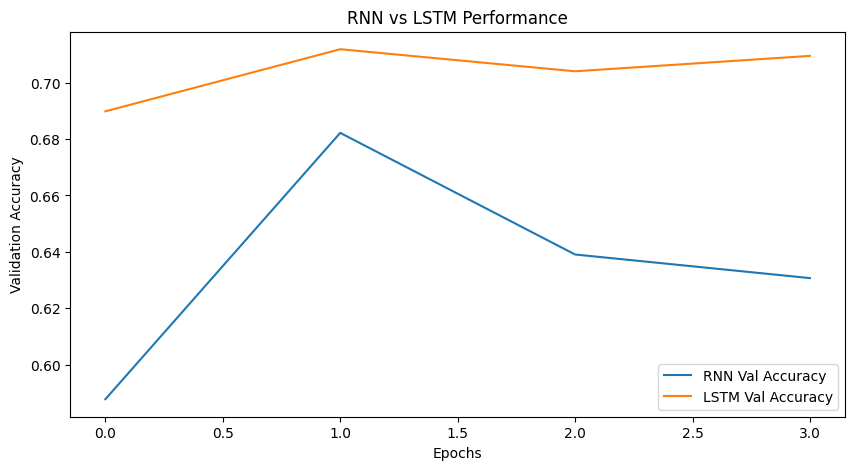

In [24]:
plt.figure(figsize=(10,5))

plt.plot(history_rnn.history['val_accuracy'], label='RNN Val Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM Val Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('RNN vs LSTM Performance')
plt.legend()

plt.show()

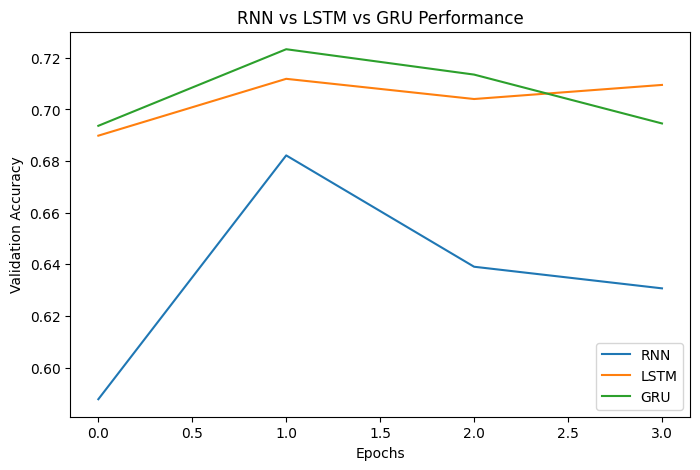

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_rnn.history['val_accuracy'], label='RNN')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM')
plt.plot(history_gru.history['val_accuracy'], label='GRU')

plt.title('RNN vs LSTM vs GRU Performance')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()

In [26]:

rnn_loss, rnn_acc = rnn_model.evaluate(X_test, y_test)
print("RNN Test Accuracy:", rnn_acc)


lstm_loss, lstm_acc = lstm_model.evaluate(X_test, y_test)
print("LSTM Test Accuracy:", lstm_acc)


gru_loss, gru_acc = gru_model.evaluate(X_test, y_test)
print("GRU Test Accuracy:", gru_acc)

172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6808 - loss: 0.7569
RNN Test Accuracy: 0.6821902990341187
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7084 - loss: 0.6877
LSTM Test Accuracy: 0.7118428349494934
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7216 - loss: 0.6746
GRU Test Accuracy: 0.7233036160469055


In [28]:
print("\nFinal Model Accuracies:")
print(f"RNN Accuracy  : {rnn_acc:.4f}")
print(f"LSTM Accuracy : {lstm_acc:.4f}")
print(f"GRU Accuracy  : {gru_acc:.4f}")


Final Model Accuracies:
RNN Accuracy  : 0.6822
LSTM Accuracy : 0.7118
GRU Accuracy  : 0.7233


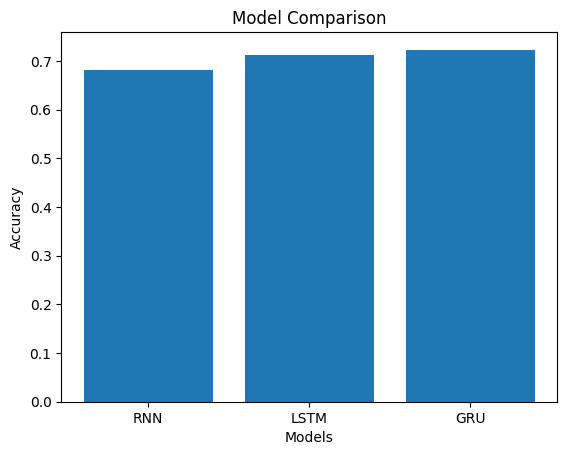

In [29]:
models = ['RNN', 'LSTM', 'GRU']
accuracies = [rnn_acc, lstm_acc, gru_acc]

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.show()